# Online Retail II: cohort retention and revenue

**Audience.** An analyst who wants the descriptive half of `clvkit`, which reports
what the transaction log already says before any model is fit.

**Prerequisites.** `uv sync`, plus network access on the first run. This notebook
downloads the UCI *Online Retail II* dataset, 43 MB, and caches it under
`examples/data/`. Later runs are offline.

**Data.** [UCI Machine Learning Repository — Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii),
licensed [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). CDNOW, used by
the other examples, ships in the repository; this is the one dataset not vendored,
so grab it from that page if you'd rather not let the notebook fetch it. Section 1
downloads and caches it automatically.

**Learning goals.** By the end you can:

1. Say what a cohort is, and build a cohort matrix by hand on six customers.
2. Clean a real retail log into the `(customer_id, date, amount)` contract every
   clvkit entry point consumes.
3. Build a `CohortMatrix` of retention and one of revenue, and read the triangle.
4. Say why an unobserved cell is `NaN` and never `0`, and why that distinction is
   the reason the chart can be trusted.

Nothing below assumes you've built a cohort matrix before. Section 0 builds one
from six invented customers you can check by counting, and only then does the real
dataset arrive.

If you're coming from `examples/cdnow_clv.ipynb`, none of the BTYD vocabulary
carries over. There's no model here, no likelihood, and no `recency`.

## Outline

0. What a cohort matrix is, on six customers
1. Fetch and cache the dataset
2. Line items to the transaction-log contract
3. Retention, and the triangle
4. Revenue, the same pivot with a different cell
5. Relative against absolute, and getting the data out
6. Exercise

## 0. What a cohort matrix is, on six customers

### The idea

"Retention was 34% last month" is a number that can't be acted on, because it
mixes customers who arrived two years ago with customers who arrived in March. A
**cohort** unmixes them: everyone who made their first purchase in the same period
is grouped together and followed forward on their own clock.

That gives a table with a specific shape:

- one **row per acquisition cohort**, labelled by the period of first purchase
- one **column per `period_number`**, meaning whole periods elapsed *since that
  cohort's own start*, so column 0 is always the cohort's own period
- one number per cell, either how many of them were active or how much they spent

Because each row runs on its own clock, the same column means "one month in" for
every cohort, whether that cohort started in 2009 or in 2011. That's the whole
trick, and it's why the columns are comparable down a page.

### The glossary

| Term | What it means here | Watch out |
| --- | --- | --- |
| **Acquisition cohort** | Every customer whose *first* observed purchase falls in the same period. | Assigned once, from the log. A customer never changes cohort. |
| **`period_number`** | Whole periods elapsed since the cohort's own period. | Column 0 is the cohort's own period, so relative column 0 is always 1.0. |
| **Retention cell** | Distinct customers of that cohort active in that period. | A customer buying three times in one month counts once. |
| **Revenue cell** | Total spend by that cohort in that period. | A sum, so one big order moves it. Retention wouldn't budge. |
| **Relative view** | Each row divided by its own column 0. | The comparable view, since cohorts differ in size. |
| **Absolute view** | Raw counts or raw currency. | Answers "how many" and "how much", not "how fast do they decay". |
| **The triangle** | Older cohorts have more observed columns, so the filled area is a triangle. | The empty corner is `NaN`, not `0`. That distinction is section 3. |

There's no `fit()` anywhere in this notebook. Every cell is a count or a sum of
things that already happened, so nothing here needs a model to be believed.

### Build one by hand

Six customers, four months, small enough to check by counting.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from clvkit import CohortMatrix

# Same role-based colours as the CDNOW notebook, validated as a set for
# colour-vision deficiency. Here they identify cohorts rather than spans.
SURFACE, INK, MUTED, GREY = "#fcfcfb", "#0b0b0b", "#52514e", "#d8d7d2"
COHORT_COLOURS = ["#2a78d6", "#eb6834", "#1baf7a"]

toy = pd.DataFrame(
    [
        ("C1", "2024-01"),
        ("C1", "2024-02"),
        ("C1", "2024-04"),
        ("C2", "2024-01"),
        ("C3", "2024-01"),
        ("C3", "2024-03"),
        ("C4", "2024-02"),
        ("C4", "2024-03"),
        ("C5", "2024-02"),
        ("C6", "2024-04"),
    ],
    columns=["customer_id", "month"],
).assign(date=lambda d: pd.to_datetime(d["month"]), amount=10.0)

toy_matrix = CohortMatrix.from_transactions(toy, period="M", metric="retention")
toy_matrix.to_pandas()

period_number,0,1,2,3
cohort,,,,
2024-01,3.0,1.0,1.0,1.0
2024-02,2.0,1.0,0.0,NaN
2024-04,1.0,NaN,NaN,NaN


Check a few cells against the list above before reading on.

Row `2024-01` holds C1, C2 and C3, so column 0 is 3. Column 1 is January's
customers active in February, which is C1 alone, so 1. Column 3 is January's
customers active in April, which is C1 again.

Row `2024-02` holds C4 and C5. Column 2 is February's customers active in April,
and neither of them bought in April, so that cell is **0**. They were watched and
they didn't come.

Row `2024-04` holds C6 alone. Columns 1 to 3 would be May, June and July, which
haven't happened. Those cells are **NaN**, and they mean something completely
different from the zero above them.

The next cell draws both halves: the log on the left, the matrix it produces on
the right.

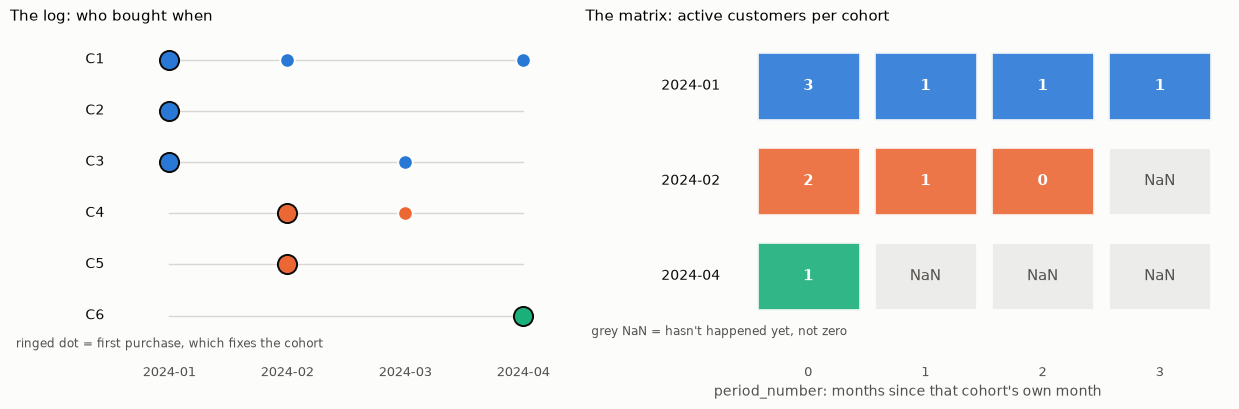

In [2]:
periods = pd.period_range("2024-01", "2024-04", freq="M")
toy_period = toy["date"].dt.to_period("M")
cohort_of = toy_period.groupby(toy["customer_id"]).min()
customers = sorted(toy["customer_id"].unique(), key=lambda c: (cohort_of[c], c))
colour_of = {p: COHORT_COLOURS[i] for i, p in enumerate(sorted(cohort_of.unique()))}

fig, (left, right) = plt.subplots(1, 2, figsize=(12.5, 4.2), width_ratios=[1, 1.15])
fig.patch.set_facecolor(SURFACE)

# ---- left: the raw log -------------------------------------------------------
left.set_facecolor(SURFACE)
for row, cid in enumerate(customers):
    y = len(customers) - row - 1
    colour = colour_of[cohort_of[cid]]
    bought = toy_period[toy["customer_id"] == cid]
    left.plot([0, len(periods) - 1], [y, y], color=GREY, lw=1, zorder=1)
    for p in bought:
        x = (p - periods[0]).n
        first = p == cohort_of[cid]
        left.scatter(
            x,
            y,
            s=190 if first else 110,
            color=colour,
            zorder=3,
            edgecolor=INK if first else SURFACE,
            linewidth=1.4,
        )
    left.text(-0.55, y, cid, va="center", ha="right", fontsize=10, color=INK)

left.set_xticks(range(len(periods)), [str(p) for p in periods], fontsize=9)
left.set_yticks([])
left.set_xlim(-1.35, len(periods) - 0.6)
left.set_ylim(-0.9, len(customers) - 0.4)
left.set_title("The log: who bought when", loc="left", fontsize=11)
left.text(
    -1.3,
    -0.62,
    "ringed dot = first purchase, which fixes the cohort",
    fontsize=8.5,
    color=MUTED,
)
for side in ("top", "right", "left", "bottom"):
    left.spines[side].set_visible(False)
left.tick_params(colors=MUTED, length=0)

# ---- right: the matrix it produces -------------------------------------------
right.set_facecolor(SURFACE)
grid = toy_matrix.to_pandas()
for row, (cohort, values) in enumerate(grid.iterrows()):
    y = len(grid) - row - 1
    for col, value in enumerate(values):
        observed = pd.notna(value)
        right.add_patch(
            plt.Rectangle(
                (col - 0.44, y - 0.36),
                0.88,
                0.72,
                facecolor=colour_of[cohort] if observed else "#ececea",
                alpha=0.9 if observed else 1.0,
                edgecolor=SURFACE,
                linewidth=2,
            )
        )
        right.text(
            col,
            y,
            f"{value:.0f}" if observed else "NaN",
            ha="center",
            va="center",
            fontsize=11,
            color="white" if observed else MUTED,
            fontweight="bold" if observed else "normal",
        )
    right.text(-0.75, y, str(cohort), va="center", ha="right", fontsize=10, color=INK)

right.set_xticks(range(grid.shape[1]), [str(c) for c in grid.columns], fontsize=9)
right.set_yticks([])
right.set_xlim(-1.9, grid.shape[1] - 0.4)
right.set_ylim(-0.9, len(grid) - 0.4)
right.set_xlabel("period_number: months since that cohort's own month", color=MUTED)
right.set_title("The matrix: active customers per cohort", loc="left", fontsize=11)
right.text(
    -1.85, -0.62, "grey NaN = hasn't happened yet, not zero", fontsize=8.5, color=MUTED
)
for side in ("top", "right", "left", "bottom"):
    right.spines[side].set_visible(False)
right.tick_params(colors=MUTED, length=0)

fig.tight_layout()

The left panel is the log. The right panel is the same information counted
differently, and every number on the right can be traced back to dots on the left.

Two cells are worth staring at, because they look alike and aren't.

The `2024-02` row ends with a solid **0** at `period_number = 2`. April happened,
February's cohort was there to be counted, and nobody bought. That's a fact about
the customers.

The `2024-04` row is grey from `period_number = 1` onwards. May hasn't happened.
That's a fact about the *window*, not about the customers, and filling it with 0
would invent a churn event out of a calendar. This is why `CohortMatrix` returns a
triangle, and why the retention matrix is float-typed even though it counts whole
customers: those `NaN`s have to live somewhere.

Now the same operation on 5,878 real customers.

## 1. Fetch and cache the dataset

**Online Retail II** is a UK gift-ware retailer's transaction log from December
2009 to December 2011: 1,067,371 line items and 5,878 identified customers. CDNOW
is a single 1997 acquisition cohort, so it can't demonstrate a cohort matrix at
all. Here customers keep arriving across the two years, which yields 25 natural
monthly acquisition cohorts.

It's CC BY 4.0 and redistributable, but it is fetched rather than vendored. 43 MB
in every clone forever costs more than the offline build is worth. The cost of
that choice: a UCI outage turns this notebook red in CI, and that is the only part
of the build depending on a third party being up.

Source: <https://archive.ics.uci.edu/dataset/502/online+retail+ii>. Cited in
`docs/references.md` under Data.

In [3]:
import urllib.request
import zipfile
from pathlib import Path

URL = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"

# Anchored to the repo, not to Path.cwd(), so the 43 MB download and the exported
# artifacts land where .gitignore covers them however the kernel was started.
REPO = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "CDNOW_sample.txt").exists()
)
DATA = REPO / "examples" / "data"
OUTPUT = REPO / "examples" / "output"
DATA.mkdir(parents=True, exist_ok=True)
OUTPUT.mkdir(parents=True, exist_ok=True)

archive = DATA / "online_retail_ii.zip"
workbook = DATA / "online_retail_II.xlsx"

if not workbook.exists():
    if not archive.exists():
        print(f"downloading {URL} ...")
        urllib.request.urlretrieve(URL, archive)
    with zipfile.ZipFile(archive) as zf:
        zf.extract("online_retail_II.xlsx", DATA)

print(f"{workbook} ({workbook.stat().st_size / 1e6:.0f} MB)")

/Users/nasserboan/projects/personal/proj-clv/examples/data/online_retail_II.xlsx (46 MB)


The workbook holds one sheet per year. Reading both takes about 20 seconds, and
there's no faster path that keeps the source honest.

In [4]:
sheets = pd.read_excel(workbook, sheet_name=None)
lines = pd.concat(sheets.values(), ignore_index=True)

print({name: len(df) for name, df in sheets.items()})
lines.head()

{'Year 2009-2010': 525461, 'Year 2010-2011': 541910}


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Line items to the transaction-log contract

The real-world warts, and what each one does to a cohort matrix if it survives:

| Wart | Rows dropped | Why it goes |
| --- | --- | --- |
| Missing `Customer ID` | 243,007 (22.8%) | No customer, no cohort. These are unidentified walk-up sales. |
| Cancellations, `Invoice` starting `C` | 18,744 (1.8%) | Negative quantities. A refund isn't a purchase event. |
| Non-positive `Quantity` or `Price` | 71 (0.01%) | Adjustments and write-offs, not trade. |

Then line items aggregate to invoices, because one basket is one purchase event.
`clvkit` reads a log of purchase events rather than of SKUs, and the difference
has teeth. A 40-line Christmas order is one act of buying, not forty, and feeding
the line items straight in would tell every model that this customer shops 40
times a day.

In [5]:
clean = lines.dropna(subset=["Customer ID"])
clean = clean[~clean["Invoice"].astype(str).str.startswith("C")]
clean = clean[(clean["Quantity"] > 0) & (clean["Price"] > 0)]
clean = clean.assign(
    customer_id=clean["Customer ID"].astype("int64"),
    line_amount=clean["Quantity"] * clean["Price"],
)

orders = clean.groupby(["customer_id", "Invoice"], as_index=False).agg(
    date=("InvoiceDate", "min"),
    amount=("line_amount", "sum"),
)

print(f"{len(lines):,} line items -> {len(clean):,} kept -> {len(orders):,} orders")
print(
    f"{orders['customer_id'].nunique():,} customers, "
    f"{orders['date'].min():%Y-%m-%d} to {orders['date'].max():%Y-%m-%d}"
)
orders.head()

1,067,371 line items -> 805,549 kept -> 36,969 orders
5,878 customers, 2009-12-01 to 2011-12-09


,customer_id,Invoice,date,amount
0,12346,491725,2009-12-14 08:34:00,45.0
1,12346,491742,2009-12-14 11:00:00,22.5
2,12346,491744,2009-12-14 11:02:00,22.5
3,12346,492718,2009-12-18 10:47:00,22.5
4,12346,492722,2009-12-18 10:55:00,1.0


805,549 of 1,067,371 line items survive, and they collapse into 36,969 orders.
That's 137 line items per customer against 6.3 purchases per customer. Feed the
line items in and every model here is told this base shops 20 times more often
than it does.

## 3. Retention, and the triangle

`CohortMatrix` is the one part of `clvkit` with no likelihood, no fitting and no
parameters. Every cell is an observed count or an observed sum, so nothing here
needs the BTYD canon to be believed. There is no `fit()`, because a pivot has no
state to estimate.

It reads the raw log rather than a `CustomerBase`. An RFM summary keeps only
first and last purchase timing, and a cohort matrix needs the whole per-period
activity pattern. A customer who bought in months 0, 3 and 7 is indistinguishable
in RFM from one who bought in 0, 5 and 7.

In [6]:
retention = CohortMatrix.from_transactions(orders, period="M", metric="retention")
print(repr(retention))

retention.to_pandas(relative=True).iloc[:6, :8].round(3)

<CohortMatrix 'retention' 25 cohorts x 25 'M' periods>


period_number,0,1,2,3,4,5,6,7
cohort,,,,,,,,
2009-12,1.0,0.353,0.334,0.425,0.380,0.359,0.377,0.342
2010-01,1.0,0.206,0.311,0.305,0.264,0.300,0.258,0.230
2010-02,1.0,0.238,0.225,0.291,0.246,0.201,0.193,0.286
2010-03,1.0,0.190,0.230,0.242,0.233,0.203,0.246,0.302
2010-04,1.0,0.194,0.194,0.163,0.184,0.224,0.276,0.262
2010-05,1.0,0.157,0.169,0.173,0.177,0.256,0.213,0.126


Rows are acquisition cohorts, the month of a customer's first observed purchase.
Columns are whole months elapsed since that cohort's own month. Column 0 is the
cohort itself, so relative column 0 is 1.0 by construction.

The triangle is what makes the chart honest. Recent cohorts have been observed for
fewer months, so cells past a cohort's observation window are `NaN`, never `0`. A
zero means observed and nobody bought. Missing means not yet knowable. Conflating
the two is how a young cohort gets read as a cohort that churned. The cost, stated
in the class docstring: the retention matrix is float-typed even though it counts
customers, because those `NaN`s have to live somewhere.

In [7]:
absolute = retention.to_pandas()
last_cohort = absolute.index[-1]

print(f"newest cohort: {last_cohort}")
print(f"observed cells in that row: {int(absolute.loc[last_cohort].notna().sum())}")
print(f"unobserved (NaN) cells:     {int(absolute.loc[last_cohort].isna().sum())}")
print(f"\nobserved zeros anywhere in the matrix: {int((absolute == 0).sum().sum())}")

newest cohort: 2011-12
observed cells in that row: 1
unobserved (NaN) cells:     24

observed zeros anywhere in the matrix: 0


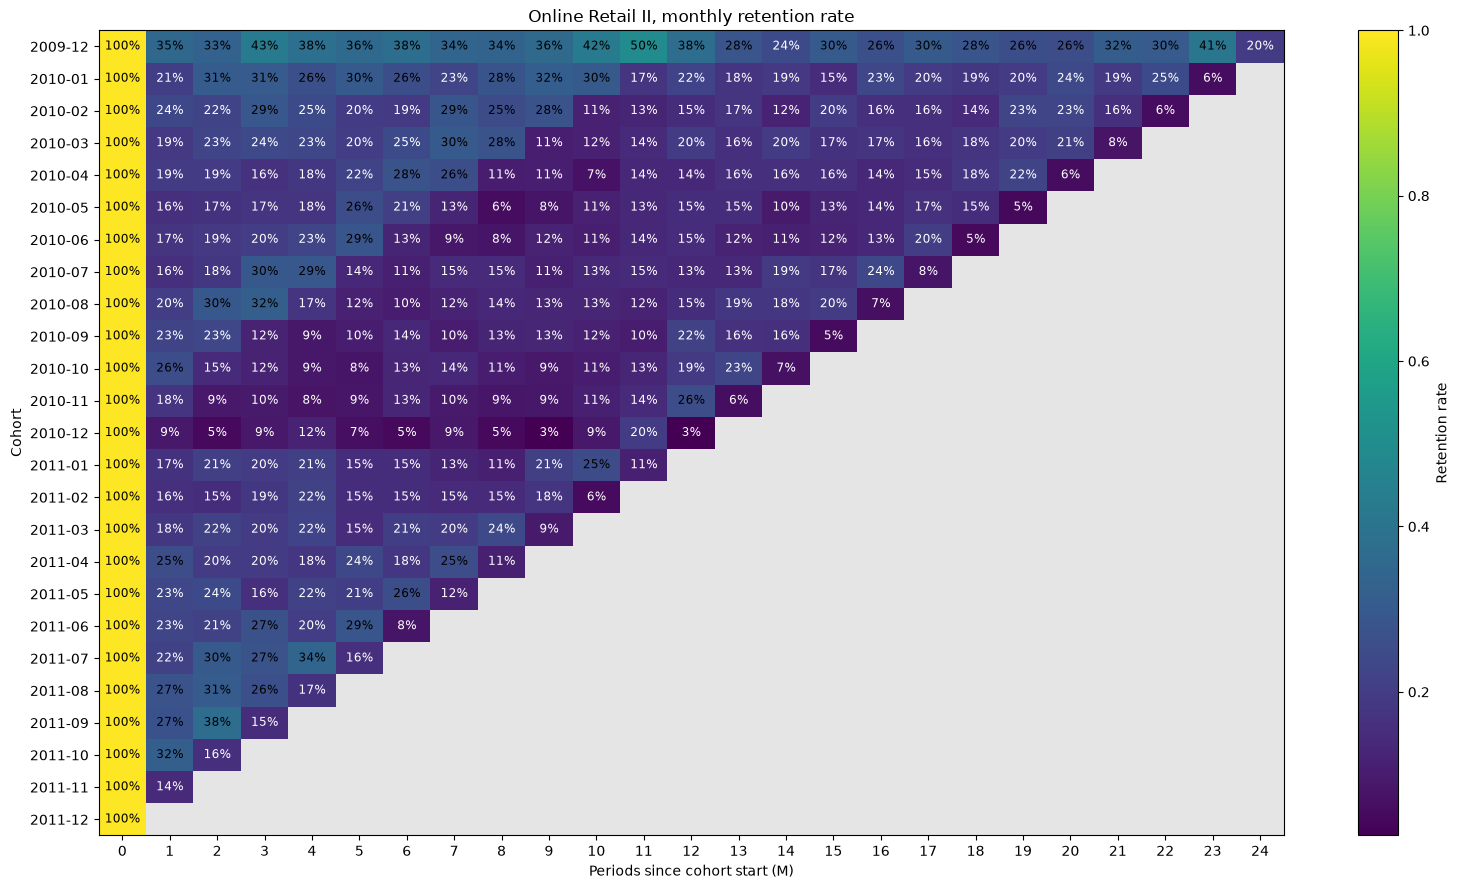

In [8]:
fig, ax = plt.subplots(figsize=(16, 9))
retention.plot(ax=ax, relative=True)
ax.set_title("Online Retail II, monthly retention rate")
fig.tight_layout()
fig.savefig(OUTPUT / "online_retail_ii_retention.png", dpi=110)

Unobserved cells are drawn in flat grey and left unlabelled, so the eye never
reads them as a cohort that dropped to zero.

The 2009-12 row is the one to read across. It's the only cohort observed for the
full two years, and it holds 33% to 50% of its customers month after month, while
the twelve cohorts acquired during 2010 average 17% to 20% over their first six
months. Roughly double, and it holds for two solid years.

That gap is the surprising number here, and the flattering reading is not the
likely one. December 2009 is the first month in the file, so anyone already
loyal to this retailer before the data starts gets labelled a 2009-12 acquisition.
The cohort is contaminated by survivors on the left edge of the window. Every
cohort matrix built on a log that doesn't reach back to the company's founding has
this problem in its top row.

The narrower rows below are not worse cohorts. They're younger ones.

## 4. Revenue, the same pivot with a different cell

`metric="revenue"` sums amounts instead of counting distinct customers. Relative
mode then divides each cohort by its own month-0 revenue, giving a revenue index:
how much of its opening month's spend a cohort still generates.

This is the number that pays for things, and it routinely diverges from headcount
retention. A cohort can lose most of its customers and keep most of its revenue.

<CohortMatrix 'revenue' 25 cohorts x 25 'M' periods>


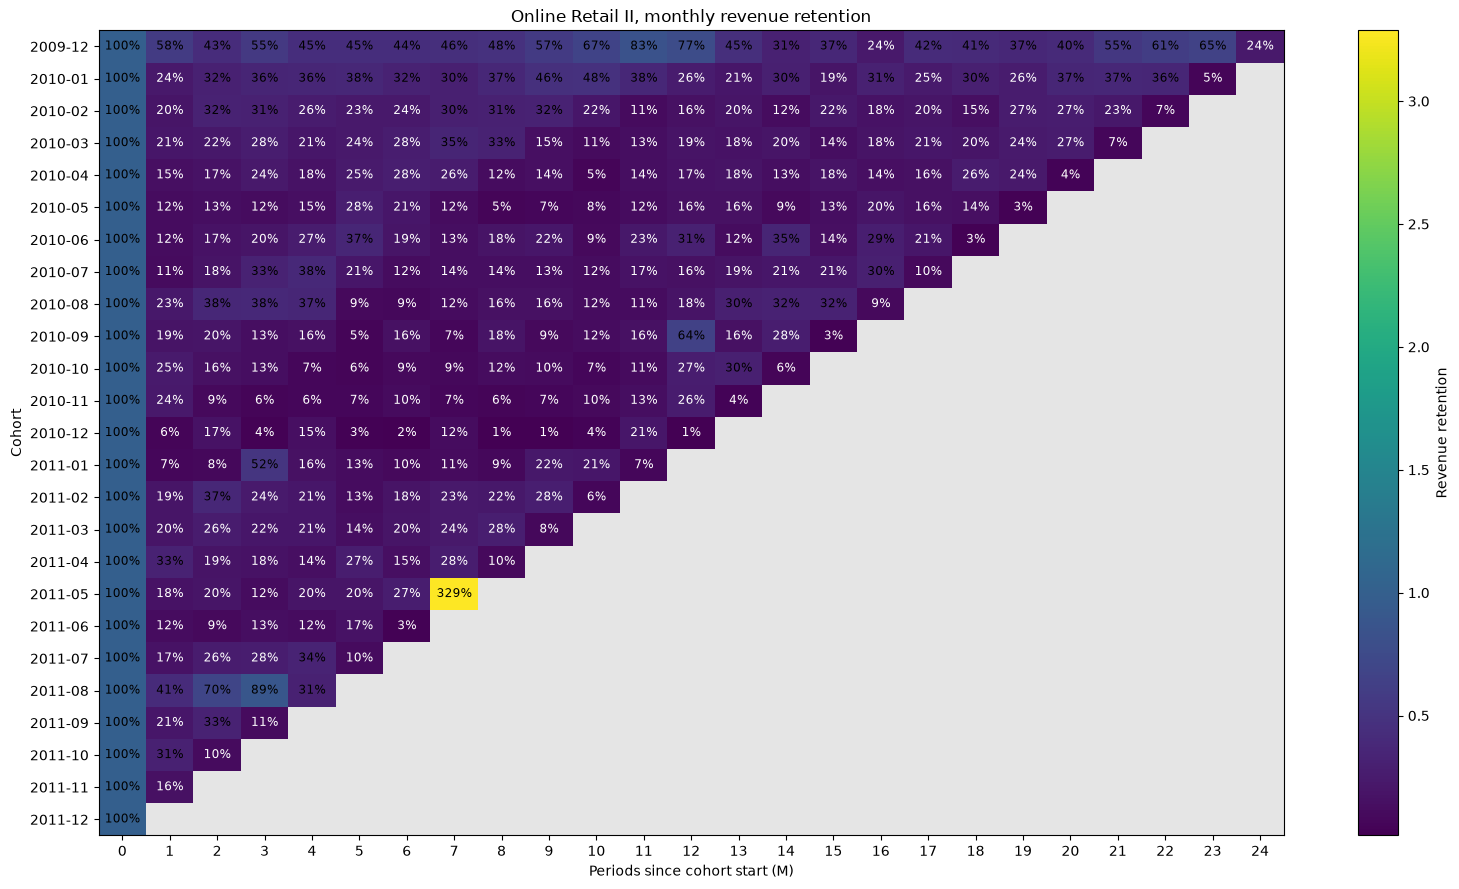

In [9]:
revenue = CohortMatrix.from_transactions(orders, period="M", metric="revenue")
print(repr(revenue))

fig, ax = plt.subplots(figsize=(16, 9))
revenue.plot(ax=ax, relative=True)
ax.set_title("Online Retail II, monthly revenue retention")
fig.tight_layout()
fig.savefig(OUTPUT / "online_retail_ii_revenue.png", dpi=110)

In [10]:
oldest = retention.to_pandas().index[0]
side_by_side = pd.DataFrame(
    {
        "customer_retention": retention.to_pandas(relative=True).loc[oldest],
        "revenue_retention": revenue.to_pandas(relative=True).loc[oldest],
    }
).dropna()

side_by_side.head(13).round(3)

,customer_retention,revenue_retention
period_number,,
0,1.000,1.000
1,0.353,0.576
2,0.334,0.432
3,0.425,0.553
4,0.380,0.447
5,0.359,0.446
6,0.377,0.441
7,0.342,0.457
8,0.336,0.484


Revenue retention beats customer retention in 23 of the 2009-12 cohort's 25
months. At month 11 it's 49.5% of the customers producing 83.5% of the opening
month's revenue. The ones who stayed are the ones who spend, so reporting only
the left-hand column understates what the cohort is worth by a factor that grows
over its life.

## 5. Relative against absolute, and getting the data out

`plot()` defaults to `relative=True`, because that's what the chart is read for:
how fast each cohort decays, independent of how big it was. The absolute view
answers a different question, which is how many customers and how much money.

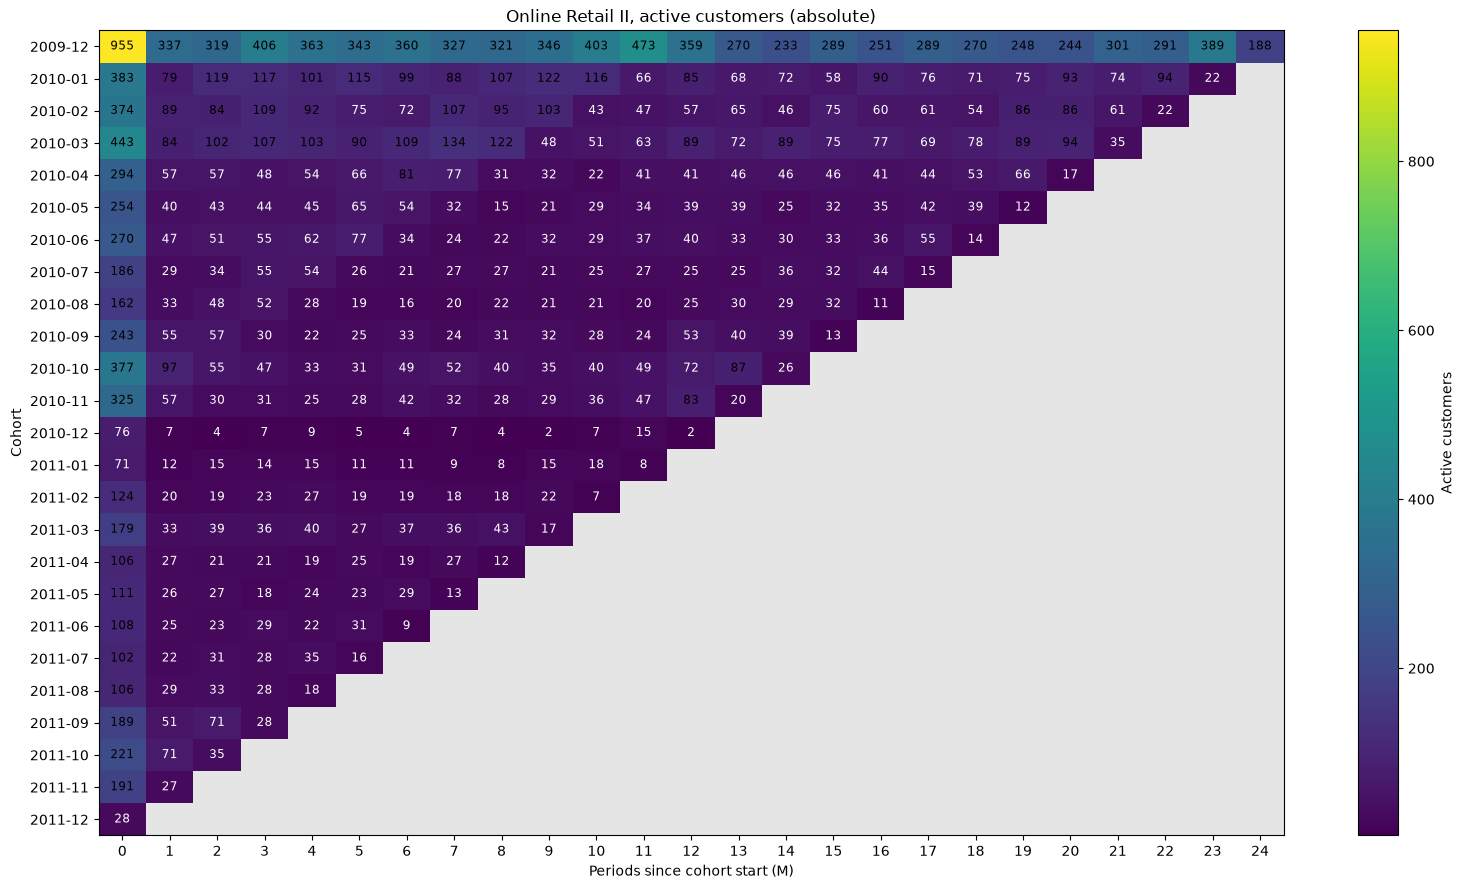

In [11]:
fig, ax = plt.subplots(figsize=(16, 9))
retention.plot(ax=ax, relative=False)
ax.set_title("Online Retail II, active customers (absolute)")
fig.tight_layout()

In [12]:
retention.to_pandas(relative=True).to_csv(OUTPUT / "online_retail_ii_retention.csv")
revenue.to_pandas(relative=True).to_csv(OUTPUT / "online_retail_ii_revenue.csv")

# to_json keeps the triangle legible outside pandas: unobserved cells are null.
print(revenue.to_json(relative=True)[:220], "...")
print("\nwrote:", *sorted(p.name for p in OUTPUT.iterdir()), sep="\n  ")

{"2009-12":{"0":1.0,"1":0.5758729708,"2":0.4322439873,"3":0.5529049587,"4":0.4469292373,"5":0.4455720329,"6":0.4410627324,"7":0.4565656895,"8":0.4842304312,"9":0.5718104438,"10":0.672265992,"11":0.8346691761,"12":0.77144 ...

wrote:
  cdnow_clv.csv
  online_retail_ii_retention.csv
  online_retail_ii_retention.png
  online_retail_ii_revenue.csv
  online_retail_ii_revenue.png


## 6. Exercise

`period` is any pandas offset alias, and it sets both the cohort grain and the
column grain, because a cohort matrix only makes sense when both use the same
clock.

Rebuild the retention matrix at `period="Q"`. Quarterly cohorts are larger and
less noisy, but you lose the within-quarter decay the monthly view shows. Which of
the two would you put in front of a finance team, and which in front of
lifecycle marketing? Run the cell below, then try `period="W"` to watch the
triangle become unreadable.

<CohortMatrix 'retention' 9 cohorts x 9 'Q' periods>


period_number,0,1,2,3,4,5,6,7,8
cohort,,,,,,,,,
2009Q4,1.0,0.631,0.648,0.591,0.695,0.497,0.498,0.485,0.56
2010Q1,1.0,0.508,0.488,0.502,0.367,0.374,0.382,0.349,NaN
2010Q2,1.0,0.390,0.435,0.220,0.306,0.281,0.308,NaN,NaN
2010Q3,1.0,0.455,0.250,0.261,0.323,0.310,NaN,NaN,NaN
2010Q4,1.0,0.204,0.240,0.208,0.348,NaN,NaN,NaN,NaN
2011Q1,1.0,0.401,0.324,0.353,NaN,NaN,NaN,NaN,NaN
2011Q2,1.0,0.428,0.391,NaN,NaN,NaN,NaN,NaN,NaN
2011Q3,1.0,0.506,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011Q4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


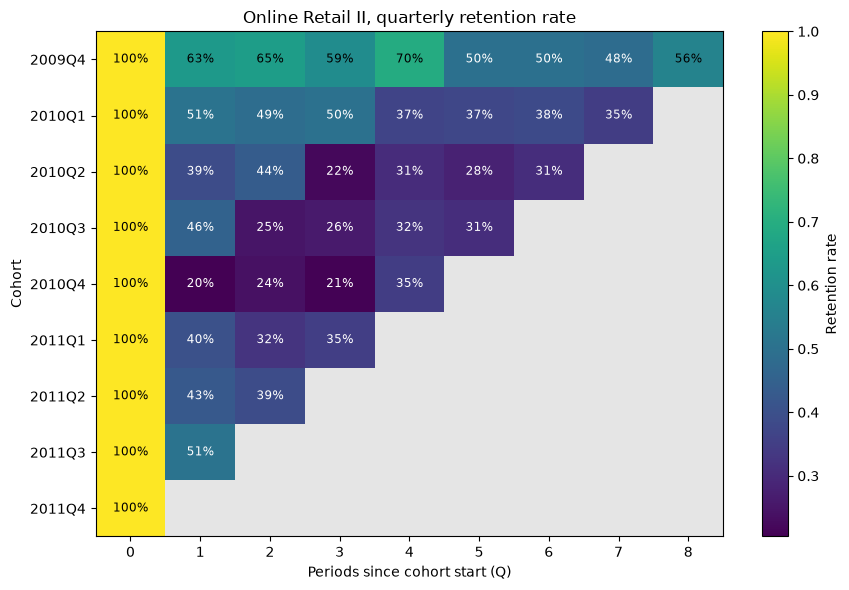

In [13]:
quarterly = CohortMatrix.from_transactions(orders, period="Q", metric="retention")
print(repr(quarterly))

fig, ax = plt.subplots(figsize=(9, 6))
quarterly.plot(ax=ax, relative=True)
ax.set_title("Online Retail II, quarterly retention rate")
fig.tight_layout()

quarterly.to_pandas(relative=True).round(3)

### Where to go next

`CohortSurvival` answers a similar question with a model behind it: aggregated
BG/NBD `P(alive)` per cohort, which extrapolates past the observation window
capping this matrix. It also carries a cost worth knowing, since a survival curve
is a cross-section across cohorts and not a panel followed forward.
`examples/cdnow_clv.ipynb` covers the modelled half, reproducing the published
Fader-Hardie estimates and composing them into lifetime value.